In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import pickle
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [3]:
# Define paths
train_folder_path = 'ImageCompression-TrainSet/'
test_folder_path = 'ImageCompression-TestSet/'

# List all image files in the folders
train_image_files = [f for f in os.listdir(train_folder_path) if f.endswith('.jpg') or f.endswith('.png')]
train_image_files.sort()  # Optional: sort files if you want a consistent order

test_image_files = [f for f in os.listdir(test_folder_path) if f.endswith('.jpg') or f.endswith('.png')]
test_image_files.sort()  # Optional: sort files if you want a consistent order

# Function to construct the CSV containing all the data points
def dataset_constructor(folder_path, image_files):
    window_size = 8
    flattened_windows = []

    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print(f"Warning: Image {image_file} not loaded properly.")
            continue

        if image.shape[0] % window_size != 0 or image.shape[1] % window_size != 0:
            print(f"Warning: Image {image_file} does not have dimensions divisible by {window_size}.")
            continue

        for i in range(0, image.shape[0], window_size):  # Outer loop for vertical movement
            for j in range(0, image.shape[1], window_size):  # Inner loop for horizontal movement
                window = image[i:i+window_size, j:j+window_size]
                flattened_windows.append(window.flatten())

    return flattened_windows

# Construct and save train data CSV
df_train = pd.DataFrame(dataset_constructor(train_folder_path, train_image_files))
train_csv_output_path = 'train_data.csv'
df_train.to_csv(train_csv_output_path, index=False)
del df_train

print(f"Data saved to {train_csv_output_path}")
train_set = pd.read_csv(train_csv_output_path)
print(f'CSV loaded. Shape: {train_set.shape}')  # Should print (number_of_images * 1024, 64) for train images

# Construct and save test data CSV
df_test = pd.DataFrame(dataset_constructor(test_folder_path, test_image_files))
test_csv_output_path = 'test_data.csv'
df_test.to_csv(test_csv_output_path, index=False)
del df_test

print(f"Data saved to {test_csv_output_path}")
test_set = pd.read_csv(test_csv_output_path)
print(f'CSV loaded. Shape: {test_set.shape}')  # Should print (number_of_images * 1024, 64) for test images

# Function to reconstruct images from the CSV files
def reconstructor(num_images, image_size, dataframe):
    window_size = 8
    reconstructed_images = []
    image_index = 0

    for i in range(num_images):
        reconstructed_image = np.zeros(image_size, dtype=np.uint8)
        for j in range(0, image_size[0], window_size):
            for k in range(0, image_size[1], window_size):
                window = dataframe.iloc[image_index].values.reshape((window_size, window_size))
                reconstructed_image[j:j+window_size, k:k+window_size] = window
                image_index += 1
        reconstructed_images.append(reconstructed_image)

    return reconstructed_images

image_size = (256, 256)
# Reconstruct images from CSV files
train_num_images = len(train_image_files)
train_reconstructed_images = reconstructor(train_num_images, image_size, train_set)

test_num_images = len(test_image_files)
test_reconstructed_images = reconstructor(test_num_images, image_size, test_set)

# Function to compare images
def compare_images(original_image, reconstructed_image):
    return np.array_equal(original_image, reconstructed_image)

# Perform sanity check
def sanity_check(folder_path, reconstructed_images, image_files):
    num_identical_images = 0

    for idx, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if original_image is None:
            print(f"Warning: Image {image_file} not loaded properly.")
            continue

        if original_image.shape != image_size:
            print(f"Warning: Image {image_file} does not have the expected dimensions {image_size}.")
            continue

        if compare_images(original_image, reconstructed_images[idx]):
            num_identical_images += 1

    return num_identical_images

train_num_identical_images = sanity_check(train_folder_path, train_reconstructed_images, train_image_files)
print(f'Number of identical images reconstructed from train set: {train_num_identical_images}/{train_num_images}')

test_num_identical_images = sanity_check(test_folder_path, test_reconstructed_images, test_image_files)
print(f'Number of identical images reconstructed from test set: {test_num_identical_images}/{test_num_images}')

del train_folder_path, test_folder_path, train_image_files, test_image_files, train_num_images, test_num_images, train_reconstructed_images, test_reconstructed_images, train_num_identical_images, test_num_identical_images

Data saved to train_data.csv
CSV loaded. Shape: (93184, 64)
Data saved to test_data.csv
CSV loaded. Shape: (5120, 64)
Number of identical images reconstructed from train set: 91/91
Number of identical images reconstructed from test set: 5/5


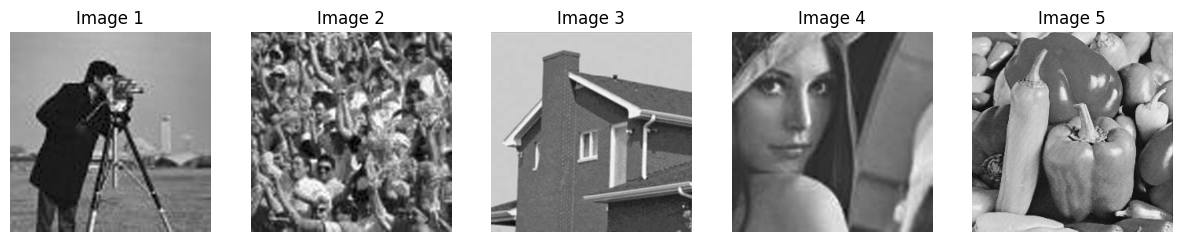

In [4]:
# just checking to see if the images are being correctly reconstructed by reconstructing test imagages
# from test set
image_size = (256, 256)

# Calculate the number of images
num_rows = test_set.shape[0]
num_images = num_rows // 1024  # Number of images = number of rows / 1024

# Reconstruct images from the test set CSV
test_reconstructed_images = reconstructor(num_images, image_size, test_set)

# Function to plot images
def plot_images(images, num_images_to_plot=5):
    plt.figure(figsize=(15, 10))
    for i in range(min(num_images_to_plot, len(images))):
        plt.subplot(1, num_images_to_plot, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f'Image {i + 1}')
        plt.axis('off')
    plt.show()

# Plot the first few reconstructed images
plot_images(test_reconstructed_images, num_images_to_plot=5)

In [5]:
class MLP:
    def __init__(self, train_set, test_set):
        self.train_set = train_set
        self.test_set = test_set
        self.epoch_number = 5
        self.learning_rate = 0.01
        self.momentum = 0.9
        self.hidden_layer_neurons = [32]
        self.layer_neurons = [64, 64]
        self.layer_neurons[1:1] = self.hidden_layer_neurons
        self.activation_type = "relu"
        self.batch_size = 128
        self.all_weights, self.all_velocities = self.initialize_weights_and_velocities()
        self.train_mse_list = []
        self.validation_mse_list = []
        self.best_val_mse = float('inf')

        self.train_datas, self.val_datas, self.test_datas = self.read_data()

    def initialize_weights_and_velocities(self):
        weights = []
        velocities = []
        for i in range(len(self.layer_neurons) - 1):
            n_in = self.layer_neurons[i]
            n_out = self.layer_neurons[i + 1]

            if self.activation_type in ["relu", "lrelu"]:
                stddev = np.sqrt(1.0 / n_in)
                layer_weights = np.random.normal(0, stddev, (n_out, n_in + 1))
            elif self.activation_type == "sigmoid":
                bound = np.sqrt(6.0 / (n_in + n_out))
                layer_weights = np.random.uniform(-bound, bound, (n_out, n_in + 1))
            else:
                raise ValueError(f"Unsupported activation function: {self.activation_type}")

            layer_velocities = np.zeros_like(layer_weights)
            weights.append(layer_weights)
            velocities.append(layer_velocities)
        return weights, velocities

    def read_data(self):
        # Normalizing the pixel values in the images
        train_datas = self.train_set / 255.0
        test_datas = self.test_set / 255.0

        train_datas, val_datas = train_test_split(train_datas.values, train_size=0.8, shuffle=False)

        return train_datas, val_datas, test_datas.values

    def activation(self, x):
        if self.activation_type == "relu":
            return np.maximum(0, x)
        elif self.activation_type == "lrelu":
            alpha = 0.01
            return np.maximum(alpha * x, x)
        elif self.activation_type == "sigmoid":
            return 1 / (1 + np.exp(-x))

    def activation_derivative(self, x):
        if self.activation_type == "relu":
            return np.where(x > 0, 1, 0)
        elif self.activation_type == "lrelu":
            alpha = 0.01
            return np.where(x > 0, 1, alpha)
        elif self.activation_type == "sigmoid":
            sigmoid_x = self.activation(x)
            return sigmoid_x * (1 - sigmoid_x)

    def forward_pass(self, data):
        data = np.append(data, [1])
        activations = [data]
        y_ins = []

        for weights in self.all_weights:
            y_in = np.dot(weights, data)
            y_ins.append(y_in)
            data = self.activation(y_in)
            data = np.append(data, [1])
            activations.append(data)

        return activations, y_ins

    def backward_pass(self, activations, y_ins, target):
        deltas = [target - activations[-1][:-1]]
        for i in range(len(self.all_weights) - 1, 0, -1):
            delta = np.dot(self.all_weights[i].T[:-1], deltas[-1]) * self.activation_derivative(y_ins[i - 1])
            deltas.append(delta)

        deltas.reverse()
        return deltas

    def update_weights(self, batch_deltas, batch_activations):
        for i in range(len(self.all_weights)):
            sum_delta_weights = np.zeros_like(self.all_weights[i][:, :-1])
            sum_delta_bias = np.zeros_like(self.all_weights[i][:, -1])
            for j in range(len(batch_activations)):
                delta_weights = self.learning_rate * np.outer(batch_deltas[j][i], batch_activations[j][i][:-1])
                delta_bias = self.learning_rate * batch_deltas[j][i]
                sum_delta_weights += delta_weights
                sum_delta_bias += delta_bias

            if self.momentum == 0.0:
                self.all_weights[i][:, :-1] += sum_delta_weights / len(batch_activations)
                self.all_weights[i][:, -1] += sum_delta_bias / len(batch_activations)
            else:
                self.all_velocities[i][:, :-1] = self.momentum * self.all_velocities[i][:, :-1] + sum_delta_weights / len(batch_activations)
                self.all_velocities[i][:, -1] = self.momentum * self.all_velocities[i][:, -1] + sum_delta_bias / len(batch_activations)

                self.all_weights[i][:, :-1] += self.all_velocities[i][:, :-1]
                self.all_weights[i][:, -1] += self.all_velocities[i][:, -1]

    def train(self):
        num_batches = int(np.ceil(len(self.train_datas) / self.batch_size))
        for epoch in range(self.epoch_number):
            # Shuffle the training data
            np.random.shuffle(self.train_datas)

            train_mse = []
            print(f"Epoch {epoch + 1}/{self.epoch_number}")
            for batch_idx in tqdm(range(num_batches), desc="Training", unit="batch"):
                batch_start = batch_idx * self.batch_size
                batch_end = (batch_idx + 1) * self.batch_size
                batch_datas = self.train_datas[batch_start:batch_end]

                batch_activations = []
                batch_deltas = []

                for data in batch_datas:
                    activations, y_ins = self.forward_pass(data)
                    output = activations[-1][:-1]
                    mse = np.mean((data - output) ** 2)
                    train_mse.append(mse)
                    deltas = self.backward_pass(activations, y_ins, data)
                    batch_activations.append(activations)
                    batch_deltas.append(deltas)

                self.update_weights(batch_deltas, batch_activations)

            epoch_mse = np.mean(train_mse)
            self.train_mse_list.append(epoch_mse)
            print(f"Train MSE: {epoch_mse}")
            self.validate()

    def validate(self):
        val_mse = []
        for data in tqdm(self.val_datas, desc="Validating", unit="image"):
            activations, _ = self.forward_pass(data)
            output = activations[-1][:-1]
            mse = np.mean((data - output) ** 2)
            val_mse.append(mse)

        epoch_mse = np.mean(val_mse)
        self.validation_mse_list.append(epoch_mse)
        print(f"Validation MSE: {epoch_mse}")

        if epoch_mse < self.best_val_mse:
            self.best_val_mse = epoch_mse
            with open('best_weights.pkl', 'wb') as f:
                pickle.dump(self.all_weights, f)
            print("Best weights updated and saved.")

        print("\n")

np.random.seed(42)
mlp = MLP(train_set, test_set)
mlp.train()

Epoch 1/5


Training: 100%|██████████| 583/583 [00:05<00:00, 115.48batch/s]


Train MSE: 0.010841104848334723


Validating: 100%|██████████| 18637/18637 [00:00<00:00, 31906.66image/s]


Validation MSE: 0.004291586177894006
Best weights updated and saved.


Epoch 2/5


...

Validation MSE: 0.002736038365170807
Best weights updated and saved.


Epoch 5/5


Training: 100%|██████████| 583/583 [00:05<00:00, 115.48batch/s]


Train MSE: 0.0028324180571921444


Validating: 100%|██████████| 18637/18637 [00:00<00:00, 32060.07image/s]

Validation MSE: 0.0025724067207776764
Best weights updated and saved.


